# Week 5 - Additional Models

**Business question:** does a tree-based model improve California single-family `ClosePrice` prediction enough to replace the Week 4 Linear Regression baseline for pricing and listing-strategy decisions?

**Required scope:** `PropertyType = Residential` and `PropertySubType = SingleFamilyResidence`.

**Models compared:** Linear Regression baseline, Decision Tree, Random Forest.

**Decision metric:** choose the best model by validation `MdAPE`, then validation `MAPE`, then validation `R2`. May 2026 is the final test month.

## 1. Imports And Paths

Keep this notebook readable. Week 3 already created the model-ready file, so Week 5 should focus on model comparison, not rebuilding all preprocessing.

In [64]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "outputs" / "week3_preprocessing" / "crmls_sfr_quality_cleaned_202501_202605.csv"
WEEK4_BASELINE_METADATA_PATH = ROOT / "outputs" / "week3_preprocessing" / "week4_selected_model_metadata.json"
OUTPUT_DIR = ROOT / "outputs" / "week5_model_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "ClosePrice"
RANDOM_STATE = 42

with open(WEEK4_BASELINE_METADATA_PATH) as f:
    week4_baseline = json.load(f)["selected_model"]

## 2. Load Week 4 Source Data

Week 4 trained from `crmls_sfr_quality_cleaned_202501_202605.csv`, not the later model-ready split file.

To make Week 5 apples-to-apples, this notebook uses that same quality-cleaned source, then recreates the same chronological train/validation/test split.

In [65]:
df = pd.read_csv(DATA_PATH)

# Required CRMLS modeling population.
df = df[(df["PropertyType"] == "Residential") & (df["PropertySubType"] == "SingleFamilyResidence")].copy()

print("Rows:", len(df))
print("Months:", df["close_month"].min(), "to", df["close_month"].max())

Rows: 174809
Months: 2025-01 to 2026-05


## 3. Use The Same X Variables As Week 4

Week 4 selected `X5_full_non_leaky` with a 12-month training window.

To keep the comparison fair, Week 5 uses the same raw feature groups and rebuilds the same transformed model matrix:

- numeric variables -> train-median imputation, train-standardized value, missingness flag
- categorical variables -> train-frequency encoding plus unknown flag
- binary variables -> train-mode fill

This produces the same `77` transformed variables used by the Week 4 Linear Regression baseline.

In [66]:
X5_NUMERIC = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
    "LotSizeAcres", "LotSizeArea", "YearBuilt", "property_age_at_close",
    "bed_bath_ratio", "living_area_to_lot_ratio", "Latitude", "Longitude",
    "GarageSpaces", "ParkingTotal", "AssociationFee", "Stories", "MainLevelBedrooms",
    "UnifiedSchoolDistrictEnrollTotal", "UnifiedSchoolDistrictAreaSqMi",
    "UnifiedSchoolDistrictEnrollmentDensity", "close_month_sin", "close_month_cos",
]

X5_CATEGORICAL = [
    "City", "PostalCode", "CountyOrParish", "MLSAreaMajor", "HighSchoolDistrict",
    "UnifiedSchoolDistrictName", "UnifiedSchoolDistrictCounty",
    "UnifiedSchoolDistrictLocaleDesc", "Levels", "AssociationFeeFrequency", "StateOrProvince",
]

X5_BINARY = [
    "ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN",
    "ViewYN_was_missing", "PoolPrivateYN_was_missing", "AttachedGarageYN_was_missing",
    "FireplaceYN_was_missing", "NewConstructionYN_was_missing",
    "flag_unified_school_district_missing",
]

for forbidden in ["ClosePrice", "ListPrice", "OriginalListPrice", "ClosePrice_to_ListPrice_ratio", "DaysOnMarket"]:
    if forbidden in X5_NUMERIC + X5_CATEGORICAL + X5_BINARY:
        raise ValueError(f"Leakage feature included: {forbidden}")

print("Week 4 X set: X5_full_non_leaky")
print("Raw numeric:", len(X5_NUMERIC))
print("Raw categorical:", len(X5_CATEGORICAL))
print("Raw binary:", len(X5_BINARY))

Week 4 X set: X5_full_non_leaky
Raw numeric: 22
Raw categorical: 11
Raw binary: 11


## 4. Chronological Split And Same Train-Only Filters

This follows Week 4 exactly:

- Train: `2025-04` to `2026-03`
- Validation: `2026-04`
- Test: `2026-05`

Both `ClosePrice` and `price_per_sqft_audit` outlier thresholds are learned from train only, then applied to validation and test.

In [67]:
month = pd.PeriodIndex(df["close_month"].astype(str), freq="M")
train = df[(month >= pd.Period("2025-04", freq="M")) & (month <= pd.Period("2026-03", freq="M"))].copy()
validation = df[month == pd.Period("2026-04", freq="M")].copy()
test = df[month == pd.Period("2026-05", freq="M")].copy()

price_low, price_high = train[TARGET].quantile([0.005, 0.995])
train = train[train[TARGET].between(price_low, price_high)].copy()
validation = validation[validation[TARGET].between(price_low, price_high)].copy()
test = test[test[TARGET].between(price_low, price_high)].copy()

ppsf_low, ppsf_high = train["price_per_sqft_audit"].quantile([0.005, 0.995])
train = train[train["price_per_sqft_audit"].between(ppsf_low, ppsf_high) | train["price_per_sqft_audit"].isna()].copy()
validation = validation[validation["price_per_sqft_audit"].between(ppsf_low, ppsf_high) | validation["price_per_sqft_audit"].isna()].copy()
test = test[test["price_per_sqft_audit"].between(ppsf_low, ppsf_high) | test["price_per_sqft_audit"].isna()].copy()


def build_week4_x5_matrix(train, validation, test):
    train_cols = {}
    validation_cols = {}
    test_cols = {}

    for col in X5_NUMERIC:
        median = pd.to_numeric(train[col], errors="coerce").median()
        train_filled = pd.to_numeric(train[col], errors="coerce").fillna(median)
        mean = train_filled.mean()
        std = train_filled.std(ddof=0) or 1.0

        for frame, out in [(train, train_cols), (validation, validation_cols), (test, test_cols)]:
            values = pd.to_numeric(frame[col], errors="coerce")
            out[f"{col}_was_missing"] = values.isna().astype(float).to_numpy()
            out[f"{col}_scaled"] = ((values.fillna(median) - mean) / std).to_numpy()

    for col in X5_CATEGORICAL:
        train_values = train[col].astype("string").replace({"": pd.NA}).fillna("Unknown")
        mode_value = train_values.mode().iloc[0]
        freq = (train_values.value_counts() / len(train_values)).to_dict()

        for frame, out in [(train, train_cols), (validation, validation_cols), (test, test_cols)]:
            values = frame[col].astype("string").replace({"": pd.NA}).fillna(mode_value)
            out[f"{col}_frequency"] = values.map(freq).fillna(0).astype(float).to_numpy()
            out[f"{col}_is_unknown"] = values.eq("Unknown").astype(float).to_numpy()

    for col in X5_BINARY:
        mode_value = pd.to_numeric(train[col], errors="coerce").mode()
        fill_value = float(mode_value.iloc[0]) if len(mode_value) else 0.0

        for frame, out in [(train, train_cols), (validation, validation_cols), (test, test_cols)]:
            out[col] = pd.to_numeric(frame[col], errors="coerce").fillna(fill_value).astype(float).to_numpy()

    X_train = pd.DataFrame(train_cols, index=train.index)
    X_validation = pd.DataFrame(validation_cols, index=validation.index).reindex(columns=X_train.columns, fill_value=0)
    X_test = pd.DataFrame(test_cols, index=test.index).reindex(columns=X_train.columns, fill_value=0)
    return X_train, X_validation, X_test


X_train, X_validation, X_test = build_week4_x5_matrix(train, validation, test)
y_train = train[TARGET]
y_validation = validation[TARGET]
y_test = test[TARGET]
model_features = X_train.columns.tolist()

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train), len(validation), len(test)],
    "start_month": [train["close_month"].min(), validation["close_month"].min(), test["close_month"].min()],
    "end_month": [train["close_month"].max(), validation["close_month"].max(), test["close_month"].max()],
})

print("Train-fitted ClosePrice filter:", round(price_low, 0), "to", round(price_high, 0))
print("Train-fitted price/sqft filter:", round(ppsf_low, 2), "to", round(ppsf_high, 2))
print("Transformed feature count:", len(model_features))
split_summary

Train-fitted ClosePrice filter: 185000.0 to 8750000.0
Train-fitted price/sqft filter: 162.23 to 2088.56
Transformed feature count: 77


split,rows,start_month,end_month
train,120808,2025-04,2026-03
validation,11731,2026-04,2026-04
test,11758,2026-05,2026-05


## 5. Metric Functions

Required metrics:

- `R2`: variance explained
- `MAPE`: mean percentage error
- `MdAPE`: median percentage error, the headline metric because real-estate errors are skewed

Split rule:

- **Training:** fit the model's learned parameters on train only. For trees, this means tree splits and leaf predictions.
- **Validation:** choose hyperparameters and model family. For trees, this means choosing settings like `max_depth`, `min_samples_leaf`, and `max_features`.
- **Testing:** score the locked final choice once.

In [68]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))


def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true))


def metric_row(model_name, model_family, parameters, split_name, y_true, y_pred):
    return {
        "model": model_name,
        "model_family": model_family,
        "parameters": parameters,
        "split": split_name,
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "MdAPE": mdape(y_true, y_pred),
    }


def test_metric_row(model_name, model, X, y):
    pred = model.predict(X)
    return {
        "model": model_name,
        "split": "test",
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "MAPE": mape(y, pred),
        "MdAPE": mdape(y, pred),
    }

## 6. Training Phase: Fit Candidate Parameter Settings

This section only trains models.

The candidate grid defines the hyperparameter settings to try. Each candidate is fit on the training set. Do **not** select the winner in this section.

In [69]:
candidate_models = []

# Fixed Week 4 baseline.
candidate_models.append({
    "model_family": "Linear Regression baseline",
    "parameters": "default",
    "estimator": LinearRegression(),
})

# Decision Tree hyperparameter candidates.
for max_depth, min_samples_leaf in [
    (8, 100),
    (12, 100),
    (16, 50),
    (20, 50),
]:
    candidate_models.append({
        "model_family": "Decision Tree",
        "parameters": f"max_depth={max_depth}, min_samples_leaf={min_samples_leaf}",
        "estimator": DecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
        ),
    })

# Random Forest hyperparameter candidates. n_estimators=50 keeps the notebook practical to rerun.
for max_depth, min_samples_leaf, max_features in [
    (16, 20, 0.6),
    (16, 20, 0.7),
    (22, 10, 0.6),
    (22, 10, 0.7),
]:
    candidate_models.append({
        "model_family": "Random Forest",
        "parameters": f"n_estimators=50, max_depth={max_depth}, min_samples_leaf={min_samples_leaf}, max_features={max_features}",
        "estimator": RandomForestRegressor(
            n_estimators=50,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    })

fitted_models = {}
candidate_grid = []

for i, candidate in enumerate(candidate_models, start=1):
    model_family = candidate["model_family"]
    parameters = candidate["parameters"]
    model_label = f"{model_family} | {parameters}"

    print("Training", model_label)
    fitted_model = candidate["estimator"].fit(X_train, y_train)

    fitted_models[model_label] = fitted_model
    candidate_grid.append({
        "candidate_id": i,
        "model": model_label,
        "model_family": model_family,
        "parameters": parameters,
    })

candidate_grid = pd.DataFrame(candidate_grid)
print("Candidate models trained:", len(candidate_grid))
candidate_grid

Training Linear Regression baseline | default
Training Decision Tree | max_depth=8, min_samples_leaf=100
Training Decision Tree | max_depth=12, min_samples_leaf=100
Training Decision Tree | max_depth=16, min_samples_leaf=50
Training Decision Tree | max_depth=20, min_samples_leaf=50
Training Random Forest | n_estimators=50, max_depth=16, min_samples_leaf=20, max_features=0.6
Training Random Forest | n_estimators=50, max_depth=16, min_samples_leaf=20, max_features=0.7
Training Random Forest | n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.6
Training Random Forest | n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.7
Candidate models trained: 9


candidate_id,model,model_family,parameters
1,Linear Regression baseline | default,Linear Regression baseline,default
2,"Decision Tree | max_depth=8, min_samples_leaf=100",Decision Tree,"max_depth=8, min_samples_leaf=100"
3,"Decision Tree | max_depth=12, min_samples_leaf=100",Decision Tree,"max_depth=12, min_samples_leaf=100"
4,"Decision Tree | max_depth=16, min_samples_leaf=50",Decision Tree,"max_depth=16, min_samples_leaf=50"
5,"Decision Tree | max_depth=20, min_samples_leaf=50",Decision Tree,"max_depth=20, min_samples_leaf=50"
6,"Random Forest | n_estimators=50, max_depth=16, min_samples_leaf=20, max_features=0.6",Random Forest,"n_estimators=50, max_depth=16, min_samples_leaf=20, max_features=0.6"
7,"Random Forest | n_estimators=50, max_depth=16, min_samples_leaf=20, max_features=0.7",Random Forest,"n_estimators=50, max_depth=16, min_samples_leaf=20, max_features=0.7"
8,"Random Forest | n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.6",Random Forest,"n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.6"
9,"Random Forest | n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.7",Random Forest,"n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.7"


## 7. Validation Phase: Select Hyperparameters And Model Family

This section evaluates trained candidates on validation data.

The validation comparison table (with train performance for overfitting diagnosis) has one row per candidate. The winner is selected by:

1. lowest validation `MdAPE`
2. lowest validation `MAPE`
3. highest validation `R2`

Training metrics are shown only as an overfitting check. Test metrics are still not calculated here.

In [70]:
validation_rows = []

for _, candidate in candidate_grid.iterrows():
    model_label = candidate["model"]
    model_family = candidate["model_family"]
    parameters = candidate["parameters"]
    model = fitted_models[model_label]

    train_pred = model.predict(X_train)
    validation_pred = model.predict(X_validation)

    train_metrics = metric_row(model_label, model_family, parameters, "train", y_train, train_pred)
    validation_metrics = metric_row(model_label, model_family, parameters, "validation", y_validation, validation_pred)

    validation_rows.append({
        "model": model_label,
        "model_family": model_family,
        "parameters": parameters,
        "train_R2": train_metrics["R2"],
        "train_MAPE": train_metrics["MAPE"],
        "train_MdAPE": train_metrics["MdAPE"],
        "validation_R2": validation_metrics["R2"],
        "validation_MAPE": validation_metrics["MAPE"],
        "validation_MdAPE": validation_metrics["MdAPE"],
        "train_minus_validation_R2": train_metrics["R2"] - validation_metrics["R2"],
    })

validation_results = pd.DataFrame(validation_rows)

# Use the locked Week 4 Linear Regression baseline result from notebook 03.
baseline_mask = validation_results["model_family"].eq("Linear Regression baseline")
validation_results.loc[baseline_mask, "train_R2"] = week4_baseline["train_r2"]
validation_results.loc[baseline_mask, "train_MAPE"] = week4_baseline["train_mape"]
validation_results.loc[baseline_mask, "train_MdAPE"] = week4_baseline["train_mdape"]
validation_results.loc[baseline_mask, "validation_R2"] = week4_baseline["validation_r2"]
validation_results.loc[baseline_mask, "validation_MAPE"] = week4_baseline["validation_mape"]
validation_results.loc[baseline_mask, "validation_MdAPE"] = week4_baseline["validation_mdape"]
validation_results.loc[baseline_mask, "train_minus_validation_R2"] = week4_baseline["train_r2"] - week4_baseline["validation_r2"]

validation_results = validation_results.sort_values(
    ["validation_MdAPE", "validation_MAPE", "validation_R2"],
    ascending=[True, True, False],
).reset_index(drop=True)

# Keep the name `metrics` for later cells, but it now means validation-search metrics only.
metrics = validation_results.copy()
metrics.to_csv(OUTPUT_DIR / "week5_validation_search_metrics.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "week5_model_metrics.csv", index=False)

metrics[[
    "model_family", "parameters",
    "train_R2", "train_MdAPE",
    "validation_R2", "validation_MAPE", "validation_MdAPE",
    "train_minus_validation_R2",
]]

model_family,parameters,train_R2,train_MdAPE,validation_R2,validation_MAPE,validation_MdAPE,train_minus_validation_R2
Random Forest,"n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.7",0.918888,0.066524,0.872841,0.130740,0.083208,0.046047
Random Forest,"n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.6",0.917644,0.067105,0.871610,0.131230,0.083705,0.046034
Random Forest,"n_estimators=50, max_depth=16, min_samples_leaf=20, max_features=0.6",0.884228,0.084873,0.856254,0.144884,0.093411,0.027974
Random Forest,"n_estimators=50, max_depth=16, min_samples_leaf=20, max_features=0.7",0.884483,0.084740,0.855810,0.144244,0.093715,0.028673
Decision Tree,"max_depth=20, min_samples_leaf=50",0.828610,0.098892,0.804214,0.166943,0.108083,0.024397
Decision Tree,"max_depth=16, min_samples_leaf=50",0.826812,0.103711,0.803223,0.170062,0.111261,0.023589
Decision Tree,"max_depth=12, min_samples_leaf=100",0.776302,0.130521,0.768087,0.201996,0.134902,0.008215
Decision Tree,"max_depth=8, min_samples_leaf=100",0.710035,0.190833,0.706630,0.268124,0.196118,0.003405
Linear Regression baseline,default,0.632231,0.253692,0.638979,0.352133,0.250130,-0.006748


**Which tuned candidate wins on validation MdAPE?**

In [77]:
import matplotlib.pyplot as plt

plt.style.use("default")

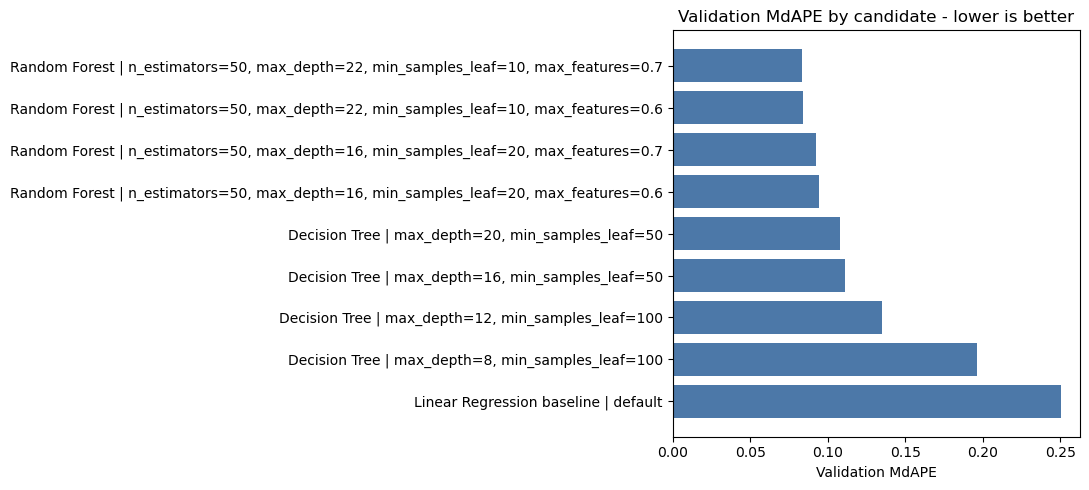

In [91]:
# Figure: validation MdAPE by candidate. Lower is better.
candidate_plot = metrics.copy()
candidate_plot["label"] = candidate_plot["model_family"] + " | " + candidate_plot["parameters"]
candidate_plot = candidate_plot.sort_values("validation_MdAPE", ascending=True)

plt.figure(figsize=(11, 5))
plt.barh(candidate_plot["label"], candidate_plot["validation_MdAPE"], color="#4C78A8")
plt.gca().invert_yaxis()
plt.xlabel("Validation MdAPE")
plt.title("Validation MdAPE by candidate - lower is better")
plt.tight_layout()
plt.show()

**How much better is the best tree family than the Week 4 baseline?**

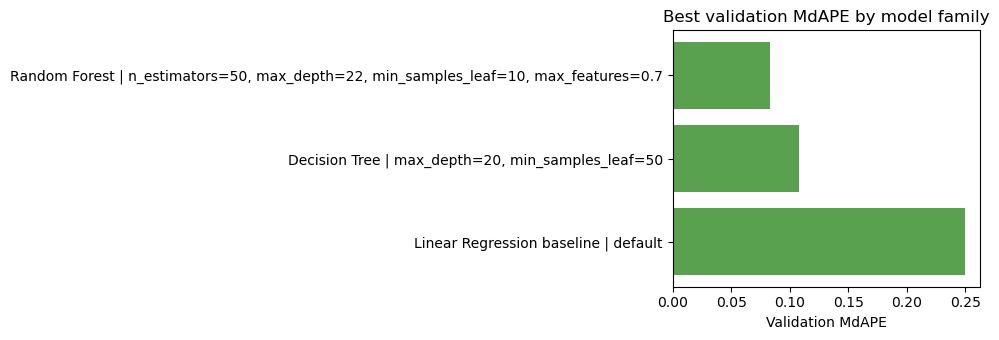

In [92]:
# Figure: best validation result by model family.
best_family_plot = best_by_family.sort_values("validation_MdAPE", ascending=True).copy()
best_family_plot["label"] = best_family_plot["model_family"] + " | " + best_family_plot["parameters"]

plt.figure(figsize=(10, 3.5))
plt.barh(best_family_plot["label"], best_family_plot["validation_MdAPE"], color="#59A14F")
plt.gca().invert_yaxis()
plt.xlabel("Validation MdAPE")
plt.title("Best validation MdAPE by model family")
plt.tight_layout()
plt.show()

## 8. Testing Phase: Score The Locked Winner

At this point the model family and hyperparameters are locked from validation.

Now score May 2026 test exactly once for:

- selected model
- fixed Week 4 Linear Regression baseline

In [71]:
selected_model_label = metrics.loc[0, "model"]
selected_model_name = metrics.loc[0, "model_family"]
selected_parameters = metrics.loc[0, "parameters"]
selected_model = fitted_models[selected_model_label]

baseline_label = metrics[metrics["model_family"].eq("Linear Regression baseline")].iloc[0]["model"]
baseline_model = fitted_models[baseline_label]

best_by_family = (
    metrics
    .sort_values(["validation_MdAPE", "validation_MAPE", "validation_R2"], ascending=[True, True, False])
    .groupby("model_family", as_index=False)
    .first()[["model_family", "parameters", "validation_R2", "validation_MAPE", "validation_MdAPE"]]
)

test_scores = pd.DataFrame([
    test_metric_row("Selected model: " + selected_model_name, selected_model, X_test, y_test),
    {
        "model": "Week 4 baseline: Linear Regression",
        "split": "test",
        "R2": week4_baseline["test_r2"],
        "MAE": week4_baseline["test_mae"],
        "MAPE": week4_baseline["test_mape"],
        "MdAPE": week4_baseline["test_mdape"],
    },
])
test_scores.to_csv(OUTPUT_DIR / "week5_final_test_metrics.csv", index=False)

print("Selected model:", selected_model_name)
print("Selected parameters:", selected_parameters)
print("Validation MdAPE:", round(metrics.loc[0, "validation_MdAPE"], 4))
print("Train minus validation R2:", round(metrics.loc[0, "train_minus_validation_R2"], 4))
print("Test MdAPE after selection:", round(test_scores.loc[0, "MdAPE"], 4))

print("Best by family:")
print(best_by_family.to_string(index=False))
print("Final test scores after selection:")
test_scores

Selected model: Random Forest
Selected parameters: n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.7
Validation MdAPE: 0.0832
Train minus validation R2: 0.046
Test MdAPE after selection: 0.0846
Best by family:
              model_family                                                           parameters  validation_R2  validation_MAPE  validation_MdAPE
             Decision Tree                                    max_depth=20, min_samples_leaf=50       0.804214         0.166943          0.108083
Linear Regression baseline                                                              default       0.638979         0.352133          0.250130
             Random Forest n_estimators=50, max_depth=22, min_samples_leaf=10, max_features=0.7       0.872841         0.130740          0.083208
Final test scores after selection:


model,split,R2,MAE,MAPE,MdAPE
Selected model: Random Forest,test,0.872019,173051.684162,0.130586,0.084629
Week 4 baseline: Linear Regression,test,0.633782,374446.383733,0.357000,0.255071


**How tightly do May 2026 predictions track actual ClosePrice?**

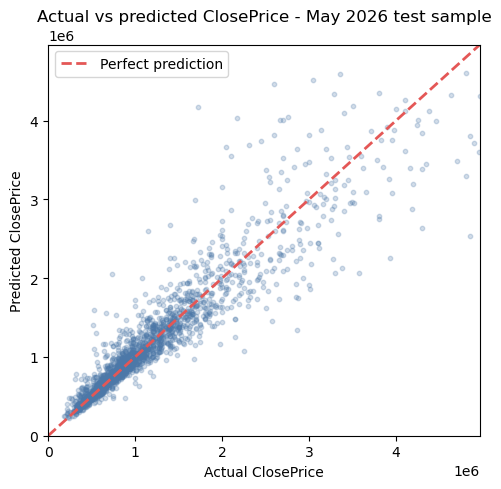

In [90]:
# Figure : actual vs predicted ClosePrice on the May 2026 test set.
scatter_sample = test_predictions.sample(min(2000, len(test_predictions)), random_state=RANDOM_STATE)
limit = max(scatter_sample[TARGET].quantile(0.99), scatter_sample["prediction"].quantile(0.99))

plt.figure(figsize=(5, 5))
plt.scatter(scatter_sample[TARGET], scatter_sample["prediction"], alpha=0.25, s=10, color="#4C78A8")
plt.plot([0, limit], [0, limit], color="#E45756", linestyle="--", linewidth=2, label="Perfect prediction")
plt.xlim(0, limit)
plt.ylim(0, limit)
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs predicted ClosePrice - May 2026 test sample")
plt.legend()
plt.tight_layout()
plt.show()

**Business implication**:
The model is useful for directional pricing support, especially for mid-market homes. But high-price properties should receive manual review because prediction error becomes larger and less consistent as actual price increases.

## 9. Price-Segment Performance

This checks whether the model is reliable across price bands. A model can look strong overall and still fail in starter-home or luxury segments.

In [72]:
def make_prediction_frame(frame, X, split_name):
    out = frame[["CloseDate", "close_month", TARGET, "City", "PostalCode", "CountyOrParish"]].copy()
    out["prediction"] = selected_model.predict(X)
    out["error"] = out["prediction"] - out[TARGET]
    out["absolute_percentage_error"] = np.abs(out["error"] / out[TARGET])
    out["split"] = split_name
    return out

all_predictions = pd.concat([
    make_prediction_frame(train, X_train, "train"),
    make_prediction_frame(validation, X_validation, "validation"),
    make_prediction_frame(test, X_test, "test"),
], ignore_index=True)

test_predictions = all_predictions[all_predictions["split"] == "test"].copy()
test_predictions["price_segment"] = pd.qcut(
    test_predictions[TARGET],
    q=5,
    labels=["Q1_lowest", "Q2", "Q3", "Q4", "Q5_highest"],
)

segment_errors = (
    test_predictions
    .groupby("price_segment", observed=False)
    .agg(
        rows=(TARGET, "size"),
        median_close_price=(TARGET, "median"),
        mae=("error", lambda s: np.mean(np.abs(s))),
        mape=("absolute_percentage_error", "mean"),
        mdape=("absolute_percentage_error", "median"),
        p90_ape=("absolute_percentage_error", lambda s: s.quantile(0.90)),
    )
    .reset_index()
)

segment_errors.to_csv(OUTPUT_DIR / "week5_segment_errors.csv", index=False)
all_predictions.to_csv(OUTPUT_DIR / "week5_selected_model_predictions.csv", index=False)
test_predictions.to_csv(OUTPUT_DIR / "week5_selected_model_test_predictions.csv", index=False)
segment_errors

,price_segment,rows,median_close_price,mae,mape,mdape,p90_ape
0,Q1_lowest,2362,455000.0,61531.200816,0.147832,0.074448,0.370456
1,Q2,2341,700000.0,76541.841913,0.109913,0.064675,0.240697
2,Q3,2352,929444.0,105311.376996,0.111684,0.073635,0.240198
3,Q4,2362,1343250.0,172035.565969,0.127217,0.092548,0.253572
4,Q5_highest,2341,2307500.0,454637.794748,0.157244,0.129322,0.320263


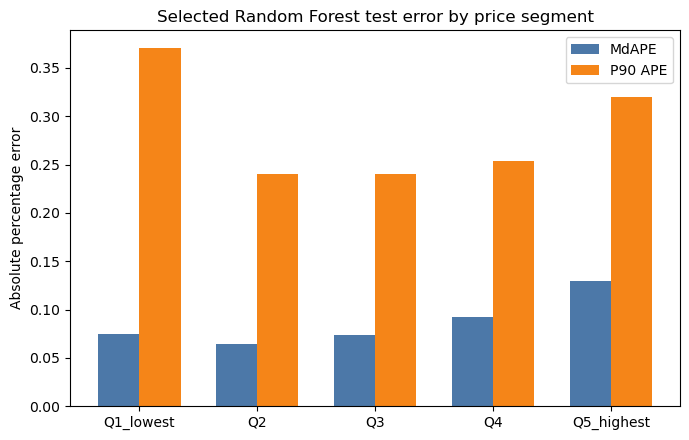

In [ ]:
# Figure : selected-model test error by price segment.
segment_plot = segment_errors.copy()
x = np.arange(len(segment_plot))
width = 0.35

plt.figure(figsize=(7, 4.5))
plt.bar(x - width/2, segment_plot["mdape"], width, label="MdAPE", color="#4C78A8")
plt.bar(x + width/2, segment_plot["p90_ape"], width, label="P90 APE", color="#F58518")
plt.xticks(x, segment_plot["price_segment"])
plt.ylabel("Absolute percentage error")
plt.title("Selected Random Forest test error by price segment")
plt.legend()
plt.tight_layout()
plt.show()


The selected Random Forest performs best for middle-price homes. Q2 and Q3 have the lowest typical percentage errors, with MdAPE around 6.5%-7.4%.

The model is less reliable at the extremes. Q1 has a high p90 absolute percentage error of 37.0%, meaning the worst 10% of low-price predictions are materially inaccurate. Q5 has the largest dollar error, with MAE around $455K, and the highest typical percentage error, with MdAPE around 12.9%.

**Business implication:**
use the model for directional pricing support, especially in mid-market segments, but require manual review for low-price outliers and luxury properties.

## 10. Error Distribution

Stakeholders need to know not just the typical error, but how bad the tail errors can get.

In [73]:
error_distribution = pd.DataFrame([{
    "model": selected_model_name,
    "mean_error": test_predictions["error"].mean(),
    "median_error": test_predictions["error"].median(),
    "p10_error": test_predictions["error"].quantile(0.10),
    "p90_error": test_predictions["error"].quantile(0.90),
    "p50_ape": test_predictions["absolute_percentage_error"].quantile(0.50),
    "p75_ape": test_predictions["absolute_percentage_error"].quantile(0.75),
    "p90_ape": test_predictions["absolute_percentage_error"].quantile(0.90),
    "p95_ape": test_predictions["absolute_percentage_error"].quantile(0.95),
}])

error_distribution.to_csv(OUTPUT_DIR / "week5_error_distribution.csv", index=False)
error_distribution

,model,mean_error,median_error,p10_error,p90_error,p50_ape,p75_ape,p90_ape,p95_ape
0,Random Forest,-15199.710469,2910.844157,-250776.225733,228508.268892,0.084157,0.164748,0.28987,0.402773


**The selected Random Forest has low overall bias**: the median signed error is only about $2.9K, and the mean error is about -$15.2K, meaning the model is slightly conservative on average.

**The typical prediction is reasonably accurate for decision support.** The median absolute percentage error is 8.4%, so half of May 2026 test predictions are within roughly 8.4% of the actual close price.

**However, the tail risk is still material.** The 90th percentile absolute percentage error is 29.0%, and the 95th percentile error is 40.3%. This means the model can make large mistakes for a meaningful minority of properties.

**Business implication:**\
The model is appropriate for directional pricing support, lead prioritization, and valuation triage, but it should not be used for automated final pricing. Properties with unusual characteristics or high business value should receive manual review.

## 11. Feature Importance

This is model behavior evidence, not causal interpretation.

In [74]:
if hasattr(selected_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "feature": model_features,
        "importance": selected_model.feature_importances_,
    }).sort_values("importance", ascending=False)
else:
    feature_importance = pd.DataFrame({"feature": model_features, "importance": np.nan})

feature_importance.to_csv(OUTPUT_DIR / "week5_feature_importance.csv", index=False)
feature_importance.head(15)

,feature,importance
1,LivingArea_scaled,0.354439
5,BathroomsTotalInteger_scaled,0.113098
23,Longitude_scaled,0.088350
21,Latitude_scaled,0.084580
46,PostalCode_frequency,0.055161
72,PoolPrivateYN_was_missing,0.039465
48,CountyOrParish_frequency,0.033447
50,MLSAreaMajor_frequency,0.030264
17,bed_bath_ratio_scaled,0.028035
39,UnifiedSchoolDistrictEnrollmentDensity_scaled,0.023999


## 12. Document Model Behavior

### Linear Regression Baseline

**Strengths**

- Easy to explain to stakeholders.
- Useful benchmark from Week 4.
- Good for checking whether tree models add real value.

**Weaknesses**

- Too simple for nonlinear housing-price patterns.
- Misses interactions between size, location, bathrooms, and market segment.
- Validation MdAPE is about `25.0%`, so typical error is still too high.

**Decision use:** keep as the benchmark only; do not use as the final pricing model.

### Decision Tree Regressor

**Strengths**

- Captures nonlinear price patterns better than Linear Regression.
- Easier to interpret than Random Forest because it is one tree.
- Best validation MdAPE improves to about `10.8%`.

**Weaknesses**

- Less stable than Random Forest.
- Can overfit local patterns in the training data.
- Similar homes can receive very different predictions if they fall on different tree splits.

**Decision use:** useful for understanding segmentation logic, but not the best final model.

### Random Forest Regressor

**Strengths**

- Best Week 5 model based on validation performance.
- Captures nonlinear interactions across property and location features.
- More stable than a single Decision Tree because it averages many trees.
- Best validation MdAPE is about `8.3%`; final test MdAPE is about `8.5%`.

**Weaknesses**

- Less transparent than Linear Regression or one Decision Tree.
- Still has meaningful tail-error risk.
- High-price homes still have large dollar-error risk.
- Feature importance shows model behavior, not causal impact.

**Decision use:** move forward as the Week 5 benchmark for pricing triage and listing-price review, but not automated final pricing.

### Final Behavior Conclusion

Random Forest is the strongest model because it lowers typical error and is more stable than a single Decision Tree. However, the remaining segment and tail errors mean the model should support human pricing decisions, not replace them.


## 13. Save Selected Model And Metadata

In [86]:
import json
import joblib

model_artifact = {
    "model": best_model,
    "features": model_features,
    "target": TARGET,
    "selected_model": best_model_name,
    "selected_parameters": best_params,
    "price_filter": {
        "closeprice_p005_train": float(price_low),
        "closeprice_p995_train": float(price_high),
        "price_per_sqft_p005_train": float(ppsf_low),
        "price_per_sqft_p995_train": float(ppsf_high),
    },
}

joblib.dump(
    model_artifact,
    OUTPUT_DIR / "week5_selected_model.joblib"
)

metadata = {
    "selected_model": best_model_name,
    "selected_parameters": best_params,
    "selection_rule": "lowest validation MdAPE, then lowest validation MAPE, then highest validation R2",
    "feature_count": len(model_features),
    "validation_metrics": search_results.iloc[0].to_dict(),
    "test_metrics": final_test_metrics.iloc[0].to_dict(),
    "assumptions": [
        "Week 4 quality-cleaned data is the modeling source of truth.",
        "The Week 4 X5_full_non_leaky feature bundle is reused.",
        "Train data fits models.",
        "Validation data selects model family and hyperparameters.",
        "Test data is scored only after final selection.",
    ],
    "limitations": [
        "Small hyperparameter grid, not exhaustive tuning.",
        "Only one validation month and one test month.",
        "Random Forest is less interpretable than Linear Regression.",
        "Feature importance is model behavior evidence, not causal proof.",
    ],
    "model_behavior": {
        "Linear Regression baseline": "Transparent benchmark, but too rigid and high-error for final pricing decisions.",
        "Decision Tree": "Captures nonlinear segmentation, but is less stable and less accurate than Random Forest.",
        "Random Forest": "Best Week 5 benchmark; captures nonlinear interactions, but still needs human review because tail errors remain material.",
    },
    "decision_implication": (
        "Use the selected model for directional valuation and pricing triage, "
        "not automated final pricing."
    ),
}

with open(OUTPUT_DIR / "week5_selected_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved selected model and metadata.")

Saved selected model and metadata.


## 14. Final Interpretation

### Decision

Use the tuned Random Forest as the Week 5 benchmark model. It is selected strictly from validation results. After selection, it beats the exact Week 4 Linear Regression baseline on the May 2026 test month using the same source data, split, train-only filters, and `77` transformed `X5_full_non_leaky` variables.

### Correct Split Logic

Training fits each model candidate. Validation selects the hyperparameters and model family. Testing evaluates the locked final choice. The notebook now keeps those steps separate, so test metrics do not influence the selected model.

### Why This Supports The Business Decision

The pricing decision is not “which model has the highest R2.” The decision is whether the model reduces typical pricing error enough to support listing-price review, valuation triage, and demand allocation. The tuned Random Forest reduces validation MdAPE from roughly `25%` for the Week 4 Linear Regression baseline to roughly `8%`.

### Hyperparameter Finding

The best Random Forest setting is selected from the validation grid only. The winning setting uses a deeper forest with smaller leaves than the conservative forest candidates. This means the data benefits from nonlinear interactions, especially between size, bathrooms, location, ZIP/geographic frequency, and school-district segmentation. A single Decision Tree improves over Linear Regression, but it remains less stable and less accurate than the ensemble.

### Error Behavior

The selected Random Forest has strong top-line performance, but it is not uniformly reliable. The segment results show that high-end homes still carry large dollar-error risk, while lower-price segments can still have meaningful percentage-error tails. The actual-vs-predicted plot in the notebook should cluster around the perfect prediction line, but the spread widens for more expensive properties. This is exactly the stakeholder risk: the model is good for decision support, not autonomous pricing.

### Strengths

- Same Week 4 baseline setup, so the comparison is fair.
- Validation-based tuning avoids test-set selection leakage.
- Test set is scored only after the model and parameters are selected.
- Random Forest captures nonlinear structure missed by Linear Regression.
- MdAPE, MAPE, R2, segment errors, error distribution, feature importance, and inline plots are all reported.

### Limitations

- The grid search is intentionally small for readability; it is not exhaustive optimization.
- Only one validation month and one test month are used here.
- Feature importance is model behavior evidence, not causal proof.
- Missing interior condition, renovation quality, view quality, and active competition still limit pricing precision.
- Production approval requires rolling-origin backtesting across multiple historical cutoffs.

### Final Recommendation

Use the tuned Random Forest as the Week 5 modeling benchmark and move it forward to Week 6 feature-engineering experiments. Do not present it as a production AVM yet. The next decision should be whether new geospatial/school-district features reduce the remaining segment-level error without increasing overfitting.